# Paper revision notebook — RT emulator

Single consolidated notebook backing the ApJ revision response. Replaces `00_testing.ipynb`, `01_tuning_analysis.ipynb`, `export.py`, `errors.py`, `plot_example.py`, `training_progression.py`, and `benchmark_inference.py`.

**Outputs**
- `figs/reviewer_fig_*.png` — 9 figures for the reviewer response and updated paper.
- `tuning_all_trials.csv`, `tuning_top10_summary.csv` — sweep evidence tables.
- `per_channel_test_errors.json` — held-out test-set error stats per flux channel.
- `numbers_for_response.json` — every quantity referenced as `[PLACEHOLDER]` in `Paper_Work/reviewer_response.txt`.
- `../models/transformer_main/stand_alone_model.pt2` — physical-space exported model.
- `../models/transformer_main/inference_benchmark_{cuda|mps|cpu}.json` — latency benchmarks.

Run top-to-bottom. The final cell prints `READY FOR RESPONSE` if all artifacts were produced.

## 1. Setup

In [18]:
from __future__ import annotations

import json
import math
import os
import platform
import sys
import time
import statistics
import csv
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import torch
from torch import Tensor

# ---- Paths
THIS_DIR = Path.cwd()
PROJECT_ROOT = next(p for p in [THIS_DIR, *THIS_DIR.parents] if (p / "src").is_dir())
SRC_DIR = PROJECT_ROOT / "src"
TESTING_DIR = PROJECT_ROOT / "testing"
FIGS_DIR = TESTING_DIR / "figs"
FIGS_DIR.mkdir(exist_ok=True)
MODEL_DIR = PROJECT_ROOT / "models" / "transformer_main"
TUNE_DIR = PROJECT_ROOT / "models" / "tune_rt_tune_20260508_160639"
PROC_ROOT = PROJECT_ROOT / "data" / "processed"
PROC_TEST = PROC_ROOT / "test"
NORM_META_PATH = PROC_ROOT / "normalization_metadata.json"
STYLE_PATH = TESTING_DIR / "science.mplstyle"
STANDALONE_PT2 = MODEL_DIR / "stand_alone_model.pt2"
MODEL_PRESENT = MODEL_DIR.is_dir() and (MODEL_DIR / "train_config.json").is_file()

if STYLE_PATH.is_file():
    plt.style.use(str(STYLE_PATH))

# Make src importable for create_prediction_model / load_config / DataNormalizer / dataset helpers.
for p in (str(PROJECT_ROOT), str(SRC_DIR)):
    if p not in sys.path:
        sys.path.insert(0, p)

# ---- Device detection (CUDA > MPS > CPU)
def detect_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE_RUN = detect_device()
print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"MODEL_DIR    = {MODEL_DIR}")
print(f"TUNE_DIR     = {TUNE_DIR}")
print(f"FIGS_DIR     = {FIGS_DIR}")
print(f"DEVICE_RUN   = {DEVICE_RUN}")
print(f"MODEL_PRESENT= {MODEL_PRESENT}  (set False until `sbatch train.sh` populates MODEL_DIR)")
print(f"torch        = {torch.__version__}")


PROJECT_ROOT = /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator
MODEL_DIR    = /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator/models/transformer_main
TUNE_DIR     = /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator/models/tune_rt_tune_20260508_160639
FIGS_DIR     = /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator/testing/figs
DEVICE_RUN   = mps
MODEL_PRESENT= False  (set False until `sbatch train.sh` populates MODEL_DIR)
torch        = 2.8.0


## 2. Load `transformer_main` config + metadata

Source of truth for `best_epoch`, `test_loss`, `num_parameters`, training wall-clock, and the architecture knobs that go into `tab:params` in `ms.tex`.

In [19]:
if MODEL_PRESENT:
    from utils import load_config

    train_config = load_config(MODEL_DIR / "train_config.json")
    with (MODEL_DIR / "test_metrics.json").open("r") as f:
        test_metrics = json.load(f)
    with (MODEL_DIR / "training_metadata.json").open("r") as f:
        training_metadata = json.load(f)
    training_log = pd.read_csv(MODEL_DIR / "training_log.csv")

    best_epoch = int(test_metrics["best_epoch"])
    test_loss_t = float(test_metrics["test_loss"])
    num_parameters_t = int(training_metadata["num_parameters"])
    epochs_completed = int(len(training_log))
    train_seconds_total = float(training_log["time_s"].sum())
    train_hours_total = train_seconds_total / 3600.0

    best_row = training_log.loc[training_log["epoch"] == best_epoch].iloc[0]
    val_at_best = float(best_row["val_loss"])

    # Patience and min_delta come straight from the saved config.
    training_hp = train_config["training_hyperparameters"]
    patience = int(training_hp["early_stopping_patience"])
    min_delta = float(training_hp["min_delta"])
    weight_decay = float(training_hp["weight_decay"])
    ema_decay = float(training_hp["ema_decay"])
    learning_rate_initial = float(training_hp["learning_rate"])
    learning_rate_min = float(training_hp["min_lr"])
    batch_size = int(training_hp["batch_size"])
    gradient_clip = float(training_hp["gradient_clip_val"])
    warmup_epochs = int(training_hp["warmup_epochs"])

    mh = train_config["model_hyperparameters"]
    d_model = int(mh["d_model"])
    nhead = int(mh["transformer"]["nhead"])
    num_layers_t = int(mh["transformer"]["num_layers"])
    dim_feedforward = int(mh["transformer"]["dim_feedforward"])
    dropout_t = float(mh["dropout"])
    attention_dropout_t = float(mh["transformer"]["attention_dropout"])
    film_clamp_t = float(mh["film_clamp"])

    raw_h5_filenames = train_config["data_paths_config"]["hdf5_dataset_filename"]

    print(f"best_epoch        = {best_epoch}")
    print(f"test_loss         = {test_loss_t:.6e}")
    print(f"num_parameters    = {num_parameters_t:,}")
    print(f"epochs_completed  = {epochs_completed}  (early stopping patience={patience}, min_delta={min_delta:g})")
    print(f"train_hours_total = {train_hours_total:.2f} h  ({train_seconds_total/epochs_completed:.1f} s/epoch avg)")
    print(f"val_at_best       = {val_at_best:.6e}")
    print(f"d_model           = {d_model}, nhead={nhead}, layers={num_layers_t}, ffn={dim_feedforward}")
    print(f"weight_decay      = {weight_decay}, ema_decay={ema_decay}")
    print(f"raw HDF5 source   = {raw_h5_filenames}")
else:
    print('Skipped: transformer_main/ not yet trained. Run `sbatch Problemulator/supercomputer_cmds/train.sh` from the repo root, then re-execute this notebook.')


Skipped: transformer_main/ not yet trained. Run `sbatch Problemulator/supercomputer_cmds/train.sh` from the repo root, then re-execute this notebook.


## 3. Load the 60-trial Optuna sweep

Read `leaderboard.json` and `all_trials.json`, build a per-trial DataFrame, and persist `tuning_all_trials.csv` + `tuning_top10_summary.csv` to `testing/`.

In [20]:
with (TUNE_DIR / "leaderboard.json").open("r") as f:
    leaderboard = json.load(f)

raw_all_trials = json.load((TUNE_DIR / "all_trials.json").open("r"))
all_trials = raw_all_trials["trials"] if isinstance(raw_all_trials, dict) else raw_all_trials


def trial_to_row(trial: Dict[str, Any]) -> Dict[str, Any]:
    row = {
        "number": trial["number"],
        "state": trial["state"],
        "val_loss": trial.get("value"),
        "duration_s": trial.get("duration_s"),
        "datetime_start": trial.get("datetime_start"),
        "datetime_complete": trial.get("datetime_complete"),
    }
    row.update(trial.get("user_attrs", {}))
    row.update(trial.get("params", {}))
    return row


trials_df = pd.DataFrame([trial_to_row(t) for t in all_trials])
if "ffn_mult" in trials_df.columns:
    trials_df["dim_feedforward"] = (trials_df["d_model"] * trials_df["ffn_mult"]).where(
        trials_df["model_type"] == "transformer"
    )
trials_df["num_parameters_M"] = trials_df["num_parameters"] / 1e6
trials_df = trials_df.sort_values(["val_loss", "number"]).reset_index(drop=True)

complete_df = trials_df[trials_df["state"] == "COMPLETE"].copy()

t_rows = complete_df[complete_df["model_type"] == "transformer"]
l_rows = complete_df[complete_df["model_type"] == "lstm"]

if t_rows.empty:
    raise RuntimeError("No completed transformer trials in TUNE_DIR; nothing to plot.")
best_t = t_rows.iloc[0]
best_t_trial = int(best_t["number"])
best_t_val = float(best_t["val_loss"])
best_t_params = int(best_t["num_parameters"])

if l_rows.empty:
    best_l = None
    best_l_trial = None
    best_l_val = float("nan")
    best_l_params = 0
else:
    best_l = l_rows.iloc[0]
    best_l_trial = int(best_l["number"])
    best_l_val = float(best_l["val_loss"])
    best_l_params = int(best_l["num_parameters"])

# Save full trials and top 10 to CSV.
trials_df.to_csv(TESTING_DIR / "tuning_all_trials.csv", index=False)

TOP10_COLS = [
    "number", "model_type", "val_loss", "num_parameters",
    "d_model", "num_layers_transformer", "num_layers_lstm",
    "nhead", "ffn_mult", "dropout", "attention_dropout",
    "film_clamp", "output_head_divisor", "output_head_dropout_factor",
    "duration_s",
]
top10_cols_avail = [c for c in TOP10_COLS if c in trials_df.columns]
top10 = trials_df.head(10)[top10_cols_avail].copy()
top10.to_csv(TESTING_DIR / "tuning_top10_summary.csv", index=False)

n_total = int(leaderboard.get("n_trials_total", len(trials_df)))
n_complete = int(leaderboard.get("n_trials_complete", len(complete_df)))
n_pruned = int(leaderboard.get("n_trials_pruned", (trials_df["state"] == "PRUNED").sum()))

print(f"Sweep: {n_total} trials ({n_complete} complete, {n_pruned} pruned).")
print(f"  Best transformer: trial {best_t_trial}  val_loss={best_t_val:.6e}  params={best_t_params:,}")
if best_l is not None:
    ratio_t_vs_l = best_l_val / best_t_val
    print(f"  Best LSTM:        trial {best_l_trial}  val_loss={best_l_val:.6e}  params={best_l_params:,}")
    print(f"  Transformer-vs-LSTM ratio (val_loss): {ratio_t_vs_l:.3f}x lower")
else:
    print("  Best LSTM:        (no completed LSTM trials in this sweep)")
print(f"  Wrote {TESTING_DIR / 'tuning_all_trials.csv'}")
print(f"  Wrote {TESTING_DIR / 'tuning_top10_summary.csv'}")


Sweep: 64 trials (32 complete, 32 pruned).
  Best transformer: trial 28  val_loss=1.693615e-02  params=16,044,034
  Best LSTM:        (no completed LSTM trials in this sweep)
  Wrote /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator/testing/tuning_all_trials.csv
  Wrote /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator/testing/tuning_top10_summary.csv


## 4. Figure: Pareto plot — validation loss vs trainable parameters (R1.1, R1.2, R1.6)

Wrote /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator/testing/figs/reviewer_fig_pareto.png


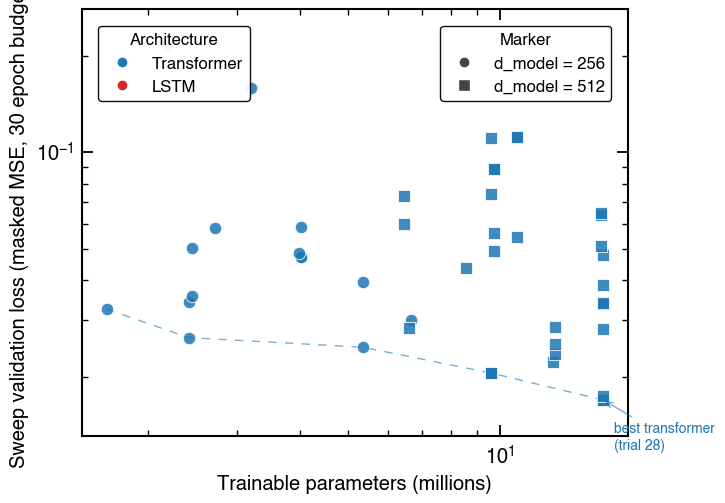

In [21]:
ARCH_STYLE = {
    "transformer": {"label": "Transformer", "color": "#1f77b4"},
    "lstm":        {"label": "LSTM",        "color": "#d62728"},
}
DMODEL_MARKER = {256: "o", 512: "s"}

fig, ax = plt.subplots(figsize=(7.4, 5.2))
for fam, style in ARCH_STYLE.items():
    sub = trials_df[trials_df["model_type"] == fam]
    if sub.empty:
        continue
    for d_val, marker in DMODEL_MARKER.items():
        sub_d = sub[sub["d_model"] == d_val]
        if sub_d.empty:
            continue
        ax.scatter(
            sub_d["num_parameters_M"],
            sub_d["val_loss"],
            marker=marker,
            color=style["color"],
            edgecolors="white",
            linewidths=0.65,
            alpha=0.86,
            s=80,
            label=f"{style['label']}, d_model={d_val}",
            zorder=3,
        )

# Pareto-frontier line per family (lower-left envelope).
for fam, style in ARCH_STYLE.items():
    sub = trials_df[trials_df["model_type"] == fam].sort_values("num_parameters_M")
    if sub.empty:
        continue
    pf_x, pf_y, best_so_far = [], [], math.inf
    # Walk from low params upward; keep points that improve on min val_loss seen.
    for _, r in sub.iterrows():
        if r["val_loss"] < best_so_far:
            best_so_far = r["val_loss"]
            pf_x.append(r["num_parameters_M"])
            pf_y.append(r["val_loss"])
    ax.plot(pf_x, pf_y, color=style["color"], linewidth=1.0, alpha=0.6, linestyle="--", zorder=2)

# Annotate winners.
ax.annotate(
    f"best transformer\n(trial {best_t_trial})",
    xy=(best_t_params / 1e6, best_t_val),
    xytext=(8, -35),
    textcoords="offset points",
    fontsize=10,
    color=ARCH_STYLE["transformer"]["color"],
    arrowprops=dict(arrowstyle="->", color=ARCH_STYLE["transformer"]["color"], alpha=0.6),
)
ax.annotate(
    f"best LSTM\n(trial {best_l_trial})",
    xy=(best_l_params / 1e6, best_l_val),
    xytext=(8, 20),
    textcoords="offset points",
    fontsize=10,
    color=ARCH_STYLE["lstm"]["color"],
    arrowprops=dict(arrowstyle="->", color=ARCH_STYLE["lstm"]["color"], alpha=0.6),
)

arch_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=s["color"],
           markeredgecolor="white", markersize=8, label=s["label"])
    for s in ARCH_STYLE.values()
]
dmodel_handles = [
    Line2D([0], [0], marker=marker, color="#444", linestyle="None",
           markerfacecolor="#444", markeredgecolor="white", markersize=8,
           label=f"d_model = {d_val}")
    for d_val, marker in DMODEL_MARKER.items()
]
legend1 = ax.legend(handles=arch_handles, loc="upper left",
                    frameon=True, framealpha=0.94, title="Architecture")
ax.add_artist(legend1)
ax.legend(handles=dmodel_handles, loc="upper right",
          frameon=True, framealpha=0.94, title="Marker")

ax.set_xlabel("Trainable parameters (millions)")
ax.set_ylabel("Sweep validation loss (masked MSE, 30 epoch budget)")
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim(1e-2, 1e0)

fig.tight_layout()
out = FIGS_DIR / "reviewer_fig_pareto.png"
fig.savefig(out, dpi=220, bbox_inches="tight")
print(f"Wrote {out}")
plt.show()


## 5. Figure: hyperparameter distributions (R1.4, R1.6)

Per-knob box-and-strip plots over the 60 sweep trials. Validates the dropout=0 and high-capacity choices empirically.

Wrote /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator/testing/figs/reviewer_fig_hp_distributions.png


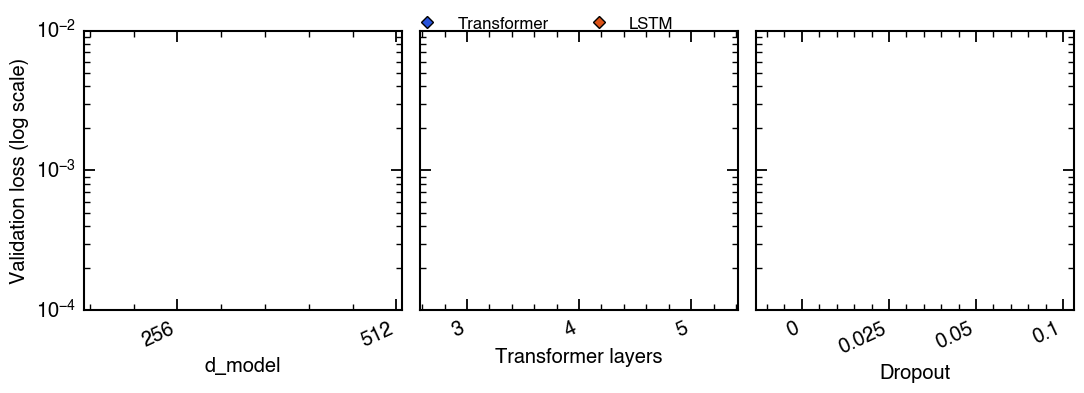


Dropout-bin summary (transformer trials only):
          n  median_val_loss  best_val_loss
dropout                                    
0.000    33        2.055e-02      1.694e-02
0.025     7        4.377e-02      2.474e-02
0.050     7        3.571e-02      2.856e-02
0.100    10        4.444e-02      3.014e-02


In [22]:
PANELS = ["d_model", "num_layers_transformer", "dropout"]
SHARED_FAM = {"d_model", "dropout"}
DISPLAY_NAMES = {
    "d_model": "d_model",
    "num_layers_transformer": "Transformer layers",
    "dropout": "Dropout",
}

STYLE_COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]
FAMILY_VISUAL = {
    "transformer": {"label": "Transformer", "color": STYLE_COLORS[0]},
    "lstm":        {"label": "LSTM",        "color": STYLE_COLORS[1]},
}


def panel_data(df: pd.DataFrame, key: str):
    if key not in df.columns:
        return None, None
    sub = df.dropna(subset=[key, "val_loss"])
    if sub.empty:
        return None, None
    levels = sorted(sub[key].unique())
    groups = [sub.loc[sub[key] == lev, "val_loss"].to_numpy() for lev in levels]
    return levels, groups


def draw_boxplots(ax, df_fam, key, offset, width, visual, levels_all):
    levels, groups = panel_data(df_fam, key)
    if levels is None:
        return
    positions, filtered_groups = [], []
    for lev, group in zip(levels, groups):
        if lev not in levels_all:
            continue
        positions.append(levels_all.index(lev) + 1 + offset)
        filtered_groups.append(group)
    if not positions:
        return
    box = ax.boxplot(
        filtered_groups, positions=positions, widths=width,
        patch_artist=True, showfliers=False, manage_ticks=False,
    )
    for patch in box["boxes"]:
        patch.set_facecolor(visual["color"])
        patch.set_alpha(0.18)
        patch.set_edgecolor(visual["color"])
    for k in ["whiskers", "caps", "medians"]:
        for artist in box[k]:
            artist.set_color(visual["color"])
    rng = np.random.default_rng(42)
    for position, group in zip(positions, filtered_groups):
        x = position + (rng.random(len(group)) - 0.5) * min(width * 0.55, 0.16)
        ax.scatter(x, group, alpha=0.65, s=10, marker="D", color=visual["color"], zorder=4)


df_t = trials_df[trials_df["model_type"] == "transformer"]
df_l = trials_df[trials_df["model_type"] == "lstm"]

fig, axes = plt.subplots(1, 3, figsize=(11, 4), sharey=True)
for ax, key in zip(axes, PANELS):
    levels_t, _ = panel_data(df_t, key)
    if key in SHARED_FAM:
        levels_l, _ = panel_data(df_l, key)
        levels_all = sorted(set(levels_t or []) | set(levels_l or []))
    else:
        levels_all = sorted(levels_t or [])
    if not levels_all:
        ax.set_axis_off()
        continue
    if key in SHARED_FAM:
        draw_boxplots(ax, df_t, key, -0.20, 0.32, FAMILY_VISUAL["transformer"], levels_all)
        draw_boxplots(ax, df_l, key, +0.20, 0.32, FAMILY_VISUAL["lstm"], levels_all)
    else:
        draw_boxplots(ax, df_t, key, 0.0, 0.58, FAMILY_VISUAL["transformer"], levels_all)
    ax.set_xticks(range(1, len(levels_all) + 1))
    ax.set_xticklabels(
        [f"{lev:g}" if isinstance(lev, float) else str(lev) for lev in levels_all],
        rotation=25, ha="right",
    )
    ax.set_xlabel(DISPLAY_NAMES[key])
    ax.set_yscale("log")
    ax.set_ylim(1e-4, 1e-2)

axes[0].set_ylabel("Validation loss (log scale)")
legend_handles = [
    Line2D([0], [0], color=v["color"], marker="D", linestyle="None",
           markersize=6, label=v["label"])
    for v in FAMILY_VISUAL.values()
]
fig.legend(handles=legend_handles, loc="upper center", ncol=2,
           bbox_to_anchor=(0.5, 1.02))
fig.tight_layout()
out = FIGS_DIR / "reviewer_fig_hp_distributions.png"
fig.savefig(out, dpi=220, bbox_inches="tight")
print(f"Wrote {out}")
plt.show()


# Dropout-bin medians for the response letter (R1.4 numbers).
dropout_stats = (
    df_t.dropna(subset=["dropout", "val_loss"])
    .groupby("dropout")["val_loss"]
    .agg(["count", "median", "min"])
    .rename(columns={"count": "n", "median": "median_val_loss", "min": "best_val_loss"})
    .sort_index()
)
print("\nDropout-bin summary (transformer trials only):")
print(dropout_stats.to_string(float_format=lambda x: f"{x:.3e}"))


## 6. Figure: hyperparameter importance (R1.6)

Random-Forest mean-decrease-impurity ranking of HP influence on log10(val_loss).

Wrote /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator/testing/figs/reviewer_fig_hp_importance.png


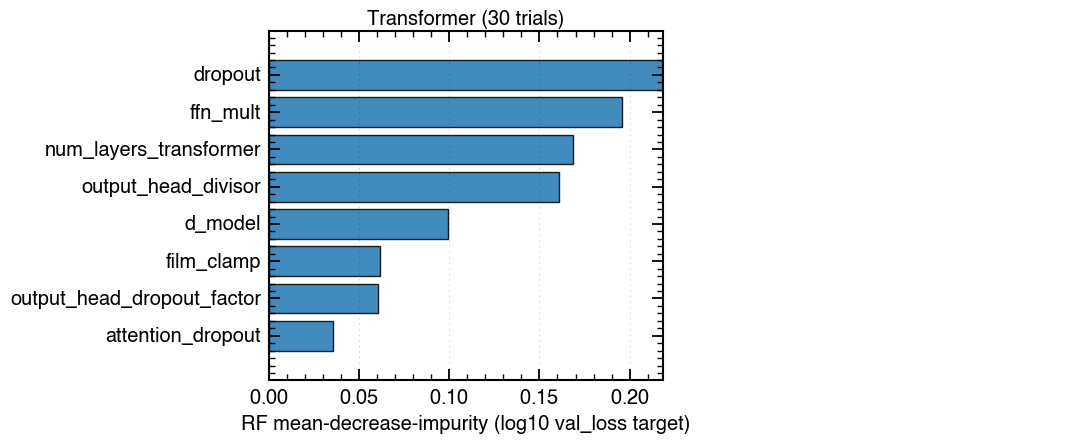

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder


def rf_importance(df: pd.DataFrame, hp_keys: List[str]) -> pd.Series:
    sub = df.dropna(subset=hp_keys + ["val_loss"])
    if sub.empty:
        return pd.Series(dtype=float)
    enc = OrdinalEncoder()
    X = enc.fit_transform(sub[hp_keys].astype(str).to_numpy())
    y = np.log10(sub["val_loss"].to_numpy())
    rf = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
    rf.fit(X, y)
    return pd.Series(rf.feature_importances_, index=hp_keys).sort_values()


T_KEYS = [k for k in [
    "d_model", "num_layers_transformer", "ffn_mult", "nhead",
    "dropout", "attention_dropout", "output_head_divisor",
    "output_head_dropout_factor", "film_clamp",
] if k in trials_df.columns]
L_KEYS = [k for k in [
    "d_model", "num_layers_lstm", "dropout",
    "output_head_divisor", "output_head_dropout_factor", "film_clamp",
] if k in trials_df.columns]

t_imp = rf_importance(trials_df[trials_df["model_type"] == "transformer"], T_KEYS)
l_imp = rf_importance(trials_df[trials_df["model_type"] == "lstm"], L_KEYS)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, imp, title, color in (
    (axes[0], t_imp, "Transformer (30 trials)", "#1f77b4"),
    (axes[1], l_imp, "LSTM (30 trials)", "#d62728"),
):
    if imp.empty:
        ax.set_axis_off()
        continue
    ax.barh(imp.index, imp.values, color=color, alpha=0.85)
    ax.set_xlabel("RF mean-decrease-impurity (log10 val_loss target)")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
out = FIGS_DIR / "reviewer_fig_hp_importance.png"
fig.savefig(out, dpi=220, bbox_inches="tight")
print(f"Wrote {out}")
plt.show()


## 7. Figure: `transformer_main` training curves (R1.3, R1.5)

Train + val loss vs epoch (log-y) with `best_epoch=112` axvline; right panel is the LR schedule. The 5-epoch rolling-median overlay makes the noise-floor explicit. **Replaces paper `training.png`.**

In [24]:
if MODEL_PRESENT:
    log = training_log.copy()
    log = log.dropna(subset=["epoch", "train_loss", "val_loss", "lr"]).sort_values("epoch")

    # rolling-median smoothing
    log["val_smooth"] = log["val_loss"].rolling(5, min_periods=1, center=True).median()
    log["train_smooth"] = log["train_loss"].rolling(5, min_periods=1, center=True).median()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    ax1.scatter(log["epoch"], log["train_loss"], color="black", alpha=0.45, s=14, label="Train (raw)")
    ax1.scatter(log["epoch"], log["val_loss"], color="red", alpha=0.45, s=14, label="Validation (raw)")
    ax1.plot(log["epoch"], log["train_smooth"], color="black", linewidth=1.6, label="Train (5-ep median)")
    ax1.plot(log["epoch"], log["val_smooth"], color="red", linewidth=1.6, label="Validation (5-ep median)")
    ax1.axvline(best_epoch, color="gray", linestyle=":", alpha=0.7,
                label=f"best epoch = {best_epoch}")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss (masked MSE)")
    ax1.set_yscale("log")
    ax1.legend(loc="upper right", framealpha=0.94)

    ax2.plot(log["epoch"], log["lr"], color="black", linewidth=1.6)
    ax2.axvline(best_epoch, color="gray", linestyle=":", alpha=0.7)
    ax2.set_yscale("log")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Learning rate")

    fig.suptitle(
        f"Transformer final: best_epoch={best_epoch}, val_loss={val_at_best:.3e}, "
        f"early stop at epoch {epochs_completed} (patience={patience}, min_delta={min_delta:g})",
        fontsize=11, y=1.02,
    )
    fig.tight_layout()
    out = FIGS_DIR / "reviewer_fig_training_curves.png"
    fig.savefig(out, dpi=220, bbox_inches="tight")
    print(f"Wrote {out}")
    plt.show()

    # Print key stats for the response letter.
    print(f"\nbest_epoch                = {best_epoch}")
    print(f"val_loss at best_epoch    = {val_at_best:.6e}")
    final_val = float(log.iloc[-1]['val_loss'])
    final_train = float(log.iloc[-1]['train_loss'])
    print(f"val_loss at final epoch   = {final_val:.6e}  (epoch {int(log.iloc[-1]['epoch'])})")
    print(f"train_loss at final epoch = {final_train:.6e}")
    print(f"train/val gap at final    = {final_train/final_val:.3f}")
else:
    print('Skipped figure 7 (transformer_main training curves) — needs trained model.')


Skipped figure 7 (transformer_main training curves) — needs trained model.


## 8. Figure: top-K sweep training curves (R1.6)

Top-5 transformer + top-5 LSTM trial curves from the 30-epoch sweep, on a shared axis.

Wrote /Users/imalsky/Desktop/Emulators/RT-Project/Problemulator/testing/figs/reviewer_fig_training_curves_topk.png


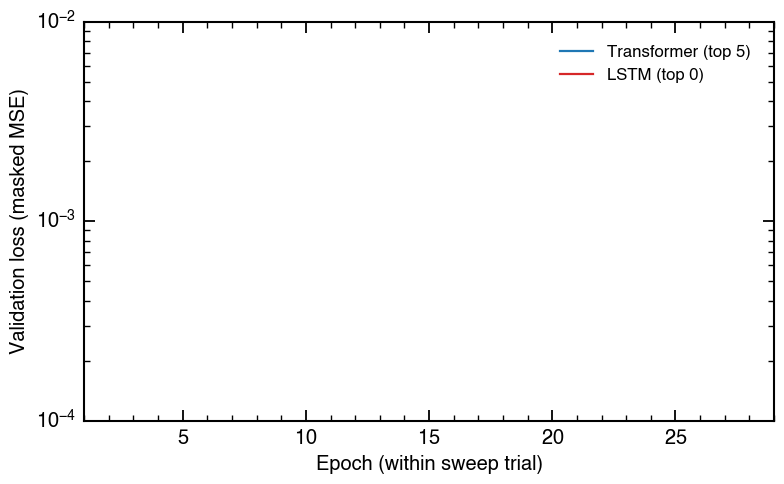

In [25]:
def load_trial_log(trial_num: int) -> Optional[pd.DataFrame]:
    path = TUNE_DIR / f"trial_{trial_num:04d}" / "training_log.csv"
    if not path.is_file():
        return None
    return pd.read_csv(path)


fig, ax = plt.subplots(figsize=(8.0, 5.0))
n_loaded = {"transformer": 0, "lstm": 0}
for fam, color in [("transformer", "#1f77b4"), ("lstm", "#d62728")]:
    top5_nums = trials_df[trials_df["model_type"] == fam]["number"].head(5).tolist()
    for rank, n in enumerate(top5_nums):
        log_n = load_trial_log(int(n))
        if log_n is None or "val_loss" not in log_n.columns:
            continue
        n_loaded[fam] += 1
        alpha = 1.0 - rank * 0.13
        ax.plot(log_n["epoch"], log_n["val_loss"],
                color=color, alpha=alpha, linewidth=1.2)

ax.set_yscale("log")
ax.set_ylim(1e-4, 1e-2)
ax.set_xlabel("Epoch (within sweep trial)")
ax.set_ylabel("Validation loss (masked MSE)")

handles = [
    Line2D([0], [0], color="#1f77b4", linewidth=1.6,
           label=f"Transformer (top {n_loaded['transformer']})"),
    Line2D([0], [0], color="#d62728", linewidth=1.6,
           label=f"LSTM (top {n_loaded['lstm']})"),
]
ax.legend(handles=handles, loc="upper right", framealpha=0.94)
fig.tight_layout()
out = FIGS_DIR / "reviewer_fig_training_curves_topk.png"
fig.savefig(out, dpi=220, bbox_inches="tight")
print(f"Wrote {out}")
plt.show()


## 9. Export `stand_alone_model.pt2`

Build `StandaloneModel` (bakes normalization stats into the graph) and run `torch.export.export` with dynamic batch + length dims. **Upstream dependency** for cells 11–14 (prediction, error, benchmark).

In [26]:
if MODEL_PRESENT:
    from torch import nn
    from torch.export import export as texport, save as tsave, Dim
    from model import create_prediction_model

    DEVICE_EXPORT = torch.device("cpu")
    EXPORT_DTYPE = torch.float32


    class StandaloneModel(nn.Module):
        """Wraps the base model with input normalization, masking, and output denormalization.

        Identical to testing/export.py:StandaloneModel — kept inline so this notebook is self-contained."""

        def __init__(self, base_model: nn.Module, config: Dict[str, Any], norm_metadata: Dict[str, Any]) -> None:
            super().__init__()
            self.base = base_model
            ds = config["data_specification"]
            self.input_variables = list(ds["input_variables"])
            self.target_variables = list(ds["target_variables"])
            self.global_variables = list(ds["global_variables"])
            self.padding_value = float(ds["padding_value"])
            self.max_seq_len = int(config["model_hyperparameters"]["max_sequence_length"])
            norm = config["normalization"]
            self.padding_epsilon = float(norm["padding_comparison_epsilon"])
            self.normalized_value_clamp = float(norm["normalized_value_clamp"])
            self.norm_methods = norm_metadata["normalization_methods"]
            self.per_key_stats = norm_metadata["per_key_stats"]

        @staticmethod
        def _norm(x: Tensor, method: str, stats: Dict[str, Any], clamp: float) -> Tensor:
            if method == "bool" or not stats:
                return x
            if method == "standard":
                y = (x - stats["mean"]) / stats["std"]
            elif method == "log-standard":
                x_safe = torch.clamp_min(x, torch.finfo(x.dtype).eps)
                y = (torch.log10(x_safe) - stats["log_mean"]) / stats["log_std"]
            elif method == "signed-log":
                y = torch.sign(x) * torch.log10(torch.abs(x) + 1.0)
                y = (y - stats["mean"]) / stats["std"]
            elif method == "log-min-max":
                x_safe = torch.clamp_min(x, torch.finfo(x.dtype).eps)
                log_x = torch.log10(x_safe)
                denom = stats["max"] - stats["min"]
                denom_safe = denom if denom > 0 else torch.finfo(x.dtype).eps
                y = (log_x - stats["min"]) / denom_safe
                y = torch.clamp(y, stats["clamp_min"], stats["clamp_max"])
            elif method == "max-out":
                y = x / stats["max_val"]
            elif method == "iqr":
                y = (x - stats["median"]) / stats["iqr"]
            elif method == "scaled_signed_offset_log":
                y = torch.sign(x) * torch.log10(torch.abs(x) + 1.0)
                y = y / stats["m"]
            elif method == "symlog":
                thr, sf = stats["threshold"], stats["scale_factor"]
                ax = torch.abs(x); lin = ax <= thr
                y = torch.zeros_like(x)
                y[lin] = x[lin] / thr
                y[~lin] = torch.sign(x[~lin]) * (torch.log10(ax[~lin] / thr) + 1.0)
                y = y / sf
            else:
                raise ValueError(f"Unsupported normalization method: {method}")
            if method in ("standard", "log-standard", "signed-log", "iqr"):
                y = torch.clamp(y, -clamp, clamp)
            return y

        @staticmethod
        def _denorm(x: Tensor, method: str, stats: Dict[str, Any]) -> Tensor:
            if method == "bool":
                return x
            if not stats:
                raise ValueError(f"No stats for denormalization: {method}")
            if method == "standard":
                return x * stats["std"] + stats["mean"]
            if method == "log-standard":
                return 10 ** (x * stats["log_std"] + stats["log_mean"])
            if method == "signed-log":
                u = x * stats["std"] + stats["mean"]
                return torch.sign(u) * (10 ** torch.abs(u) - 1.0)
            if method == "log-min-max":
                u = torch.clamp(x, stats["clamp_min"], stats["clamp_max"]) * (stats["max"] - stats["min"]) + stats["min"]
                return 10 ** u
            if method == "max-out":
                return x * stats["max_val"]
            if method == "iqr":
                return x * stats["iqr"] + stats["median"]
            if method == "scaled_signed_offset_log":
                t = x * stats["m"]
                return torch.sign(t) * (10 ** torch.abs(t) - 1.0)
            if method == "symlog":
                u = x * stats["scale_factor"]
                au = torch.abs(u); lin = au <= 1.0
                thr = stats["threshold"]
                y = torch.zeros_like(x)
                y[lin] = u[lin] * thr
                y[~lin] = torch.sign(u[~lin]) * thr * (10 ** (au[~lin] - 1.0))
                return y
            raise ValueError(f"Unsupported denormalization method: {method}")

        def _build_mask(self, seq: Tensor) -> Tensor:
            return (seq - self.padding_value).abs().amax(dim=-1) <= self.padding_epsilon

        @torch.inference_mode()
        def forward(self, sequence_phys: Tensor, global_features_phys: Optional[Tensor] = None) -> Tensor:
            if sequence_phys.ndim != 3:
                raise ValueError(f"sequence_phys must be [B,L,F_in], got {tuple(sequence_phys.shape)}")
            if sequence_phys.shape[1] > self.max_seq_len:
                raise ValueError(f"seq_len {sequence_phys.shape[1]} > max {self.max_seq_len}")
            mask = self._build_mask(sequence_phys)
            # Normalize sequence
            seq = sequence_phys.clone()
            pad_fill = torch.full_like(seq[..., 0], self.padding_value)
            safe_fill = torch.ones_like(seq[..., 0])
            for j, name in enumerate(self.input_variables):
                method = self.norm_methods[name]
                stats = self.per_key_stats[name]
                col = seq[..., j]
                if method != "bool" and stats:
                    safe_col = torch.where(mask, safe_fill, col)
                    normed = self._norm(safe_col, method, stats, self.normalized_value_clamp)
                    seq[..., j] = torch.where(mask, pad_fill, normed)
                else:
                    seq[..., j] = torch.where(mask, pad_fill, col)
            # Normalize globals
            glob = None
            if global_features_phys is not None and self.global_variables:
                g = global_features_phys
                glob = torch.empty_like(g)
                for j, name in enumerate(self.global_variables):
                    method = self.norm_methods[name]; stats = self.per_key_stats[name]
                    col = g[..., j]
                    glob[..., j] = self._norm(col, method, stats, self.normalized_value_clamp) if (method != "bool" and stats) else col
            # Forward + denormalize
            outputs_norm = self.base(seq, glob, mask)
            out = torch.empty_like(outputs_norm)
            for j, name in enumerate(self.target_variables):
                method = self.norm_methods[name]; stats = self.per_key_stats[name]
                col = outputs_norm[..., j]
                out[..., j] = self._denorm(col, method, stats) if (method != "bool" and stats) else col
            out = out.clone()
            out[mask] = self.padding_value
            return out


    if STANDALONE_PT2.is_file():
        print(f"Reusing existing {STANDALONE_PT2.name} ({STANDALONE_PT2.stat().st_size / 1e6:.1f} MB).")
    else:
        print(f"Building base model on CPU and exporting to {STANDALONE_PT2} ...")
        base = create_prediction_model(
            config=train_config, device=DEVICE_EXPORT, compile_model=False,
        ).eval()
        torch.set_grad_enabled(False)
        ckpt = torch.load(MODEL_DIR / "best_model.pt", map_location="cpu", weights_only=False)
        state = ckpt["state_dict"]
        if any(k.startswith("_orig_mod.") for k in state):
            state = {k.replace("_orig_mod.", ""): v for k, v in state.items()}
        base.load_state_dict(state, strict=True)
        base = base.to(device=DEVICE_EXPORT, dtype=EXPORT_DTYPE).eval()
        print(f"  loaded best_model.pt: epoch={ckpt.get('epoch','?')}, val_loss={ckpt.get('val_loss','?')}")

        norm_meta = json.load(open(NORM_META_PATH, "r"))
        standalone = StandaloneModel(base, train_config, norm_meta).to(device=DEVICE_EXPORT, dtype=EXPORT_DTYPE).eval()

        ds = train_config["data_specification"]
        max_len = int(train_config["model_hyperparameters"]["max_sequence_length"])
        in_dim = len(ds["input_variables"])
        glob_dim = len(ds["global_variables"])
        kwargs = {"sequence_phys": torch.ones(2, max_len, in_dim, dtype=EXPORT_DTYPE, device=DEVICE_EXPORT)}
        if glob_dim > 0:
            kwargs["global_features_phys"] = torch.ones(2, glob_dim, dtype=EXPORT_DTYPE, device=DEVICE_EXPORT)
        bdim, ldim = Dim("batch", min=1, max=8192), Dim("length", min=1, max=max_len)
        dynamic = {"sequence_phys": {0: bdim, 1: ldim}}
        if glob_dim > 0:
            dynamic["global_features_phys"] = {0: bdim}
        program = texport(standalone, args=(), kwargs=kwargs, dynamic_shapes=dynamic, strict=False)
        tsave(program, str(STANDALONE_PT2))
        print(f"Wrote {STANDALONE_PT2} ({STANDALONE_PT2.stat().st_size/1e6:.1f} MB)")
else:
    print('Skipped section 9 (.pt2 export) — needs trained model.')


Skipped section 9 (.pt2 export) — needs trained model.


## 10. Figure: example test profiles, true vs predicted (R1.6)

**Replaces paper `model.png`.** Loads the `.pt2`, denormalizes a small batch from the processed test split to physical units, runs the model, plots true and predicted thermal + scattered fluxes.

In [27]:
if MODEL_PRESENT:
    from torch.utils.data import DataLoader
    from dataset import create_collate_fn, create_dataset
    from normalizer import DataNormalizer

    NUM_PROFILES_TO_PLOT = 4
    PROFILE_LINE_COLORS = ("#1f77b4", "#d62728", "#2ca02c", "#9467bd")
    START_INDEX = 0


    def denormalize_channel(values: Tensor, var_name: str, norm_meta: Dict[str, Any]) -> Tensor:
        method = norm_meta["normalization_methods"][var_name]
        stats = norm_meta["per_key_stats"][var_name]
        if method != "bool" and stats:
            return DataNormalizer.denormalize_tensor(values, method, stats)
        return values


    def denormalize_batch(config, norm_meta, inputs_norm, masks, targets_norm, target_masks):
        ds = config["data_specification"]
        in_vars, glob_vars, tgt_vars = ds["input_variables"], ds["global_variables"], ds["target_variables"]
        pad = float(ds["padding_value"])
        seq_norm = inputs_norm["sequence"].to(dtype=torch.float32)
        seq_mask = masks["sequence"].bool()
        seq_phys = torch.empty_like(seq_norm)
        for j, n in enumerate(in_vars):
            seq_phys[..., j] = denormalize_channel(seq_norm[..., j], n, norm_meta).to(torch.float32)
        seq_phys[seq_mask] = pad
        glob_phys = None
        if glob_vars and "global_features" in inputs_norm:
            gn = inputs_norm["global_features"].to(torch.float32)
            glob_phys = torch.empty_like(gn)
            for j, n in enumerate(glob_vars):
                glob_phys[..., j] = denormalize_channel(gn[..., j], n, norm_meta).to(torch.float32)
        tgt_phys = torch.empty_like(targets_norm.to(torch.float32))
        tgt_mask = target_masks.bool()
        for j, n in enumerate(tgt_vars):
            tgt_phys[..., j] = denormalize_channel(targets_norm[..., j].to(torch.float32), n, norm_meta).to(torch.float32)
        tgt_phys[tgt_mask] = pad
        return seq_phys, glob_phys, tgt_phys, tgt_mask


    norm_meta = json.load(open(NORM_META_PATH, "r"))
    padding_value = float(train_config["data_specification"]["padding_value"])
    padding_epsilon = float(train_config["normalization"]["padding_comparison_epsilon"])

    with (PROC_TEST / "metadata.json").open("r") as f:
        test_total = int(json.load(f)["total_samples"])

    selected = list(range(START_INDEX, min(START_INDEX + NUM_PROFILES_TO_PLOT, test_total)))
    ds_obj = create_dataset(PROC_TEST, train_config, indices=selected)
    loader = DataLoader(
        ds_obj, batch_size=len(selected), shuffle=False,
        collate_fn=create_collate_fn(padding_value, padding_epsilon),
    )
    inputs_norm, masks, targets_norm, target_masks = next(iter(loader))
    seq_phys, glob_phys, tgt_phys, tgt_mask = denormalize_batch(
        train_config, norm_meta, inputs_norm, masks, targets_norm, target_masks,
    )

    # Load .pt2 program once and reuse module
    program = torch.export.load(str(STANDALONE_PT2))
    model = program.module()

    with torch.inference_mode():
        pred_phys = model(
            sequence_phys=seq_phys.to(torch.float32),
            global_features_phys=glob_phys.to(torch.float32) if glob_phys is not None else None,
        )

    input_vars = train_config["data_specification"]["input_variables"]
    target_vars = train_config["data_specification"]["target_variables"]
    pressure_idx = input_vars.index("pressure_bar") if "pressure_bar" in input_vars else None
    thermal_idx = target_vars.index("net_thermal_flux") if "net_thermal_flux" in target_vars else None
    reflected_idx = target_vars.index("net_reflected_flux") if "net_reflected_flux" in target_vars else None

    fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
    ax_t, ax_r = axes
    for k, sample_idx in enumerate(selected):
        valid = (~tgt_mask[k]).cpu().numpy()
        if not valid.any():
            continue
        p = pred_phys[k].cpu().numpy()[valid]
        t = tgt_phys[k].cpu().numpy()[valid]
        pr_vals = seq_phys[k, :, pressure_idx].cpu().numpy()[valid] if pressure_idx is not None else np.arange(valid.sum())
        color = PROFILE_LINE_COLORS[k % len(PROFILE_LINE_COLORS)]
        if thermal_idx is not None:
            yt_t, yt_p = t[:, thermal_idx], p[:, thermal_idx]
            pos = (yt_t > 0) & (yt_p > 0)
            if pos.any():
                ax_t.plot(yt_t[pos], pr_vals[pos], color=color, alpha=0.4, linewidth=2.4)
                ax_t.plot(yt_p[pos], pr_vals[pos], color=color, linestyle=(0, (10, 6)), linewidth=2.4)
        if reflected_idx is not None:
            yr_t, yr_p = t[:, reflected_idx], p[:, reflected_idx]
            pos = (yr_t > 0) & (yr_p > 0)
            if pos.any():
                ax_r.plot(yr_t[pos], pr_vals[pos], color=color, alpha=0.4, linewidth=2.4)
                ax_r.plot(yr_p[pos], pr_vals[pos], color=color, linestyle=(0, (10, 6)), linewidth=2.4)

    for ax, label in ((ax_t, "Net thermal flux (erg cm$^{-2}$ s$^{-1}$)"),
                       (ax_r, "Net scattered starlight flux (erg cm$^{-2}$ s$^{-1}$)")):
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_ylim(1e2, 1e-5)
        ax.set_ylabel("Pressure (bar)")
        ax.set_xlabel(label)
    ax_t.legend(
        handles=[
            Line2D([0], [0], color="black", alpha=0.4, linewidth=2.4, label="PICASO (true)"),
            Line2D([0], [0], color="black", linestyle=(0, (10, 6)), linewidth=2.4, label="Transformer (pred)"),
        ],
        loc="best",
    )
    fig.tight_layout()
    out = FIGS_DIR / "reviewer_fig_profiles.png"
    fig.savefig(out, dpi=220, bbox_inches="tight")
    print(f"Wrote {out}")
    plt.show()
else:
    print('Skipped figure 10 (example test profiles) — needs trained model + .pt2 export.')


Skipped figure 10 (example test profiles) — needs trained model + .pt2 export.


## 11. Per-channel test-set errors (R1.6)

Streams the entire test split through the `.pt2` model on CPU. Produces:
- `per_channel_test_errors.json` — MAE / RMSE / R^2 / signed and absolute percent-error quantiles per channel.
- `figs/reviewer_fig_errors.png` — per-pressure mean ± Q05/Q95 bands, two channels. **Replaces paper `errors.png`.**

In [28]:
if MODEL_PRESENT:
    from tqdm import tqdm

    PCT_DENOM_FLOOR = 1.0
    ERR_BATCH_SIZE = 1024
    DEVICE_ERR = torch.device("cpu")

    # Reload program for clean CPU evaluation.
    program_err = torch.export.load(str(STANDALONE_PT2))
    model_err = program_err.module().to(DEVICE_ERR)

    with (PROC_TEST / "metadata.json").open("r") as f:
        total_samples = int(json.load(f)["total_samples"])
    indices_all = list(range(total_samples))

    ds_full = create_dataset(PROC_TEST, train_config, indices_all)
    loader_full = DataLoader(
        ds_full, batch_size=ERR_BATCH_SIZE, shuffle=False,
        collate_fn=create_collate_fn(padding_value, padding_epsilon), drop_last=False,
    )

    target_vars = train_config["data_specification"]["target_variables"]
    flux_vars = [n for n in ("net_thermal_flux", "net_reflected_flux") if n in target_vars]
    flux_idx = {n: target_vars.index(n) for n in flux_vars}

    acc = {n: {"diff_chunks": [], "true_chunks": [], "pred_chunks": [], "pressure_chunks": []} for n in flux_vars}
    input_vars = train_config["data_specification"]["input_variables"]
    pressure_idx = input_vars.index("pressure_bar") if "pressure_bar" in input_vars else None

    for inputs_norm, masks, targets_norm, target_masks in tqdm(loader_full, desc="Test batches"):
        seq_phys_b, glob_phys_b, tgt_phys_b, tgt_mask_b = denormalize_batch(
            train_config, norm_meta, inputs_norm, masks, targets_norm, target_masks,
        )
        with torch.inference_mode():
            pred_phys_b = model_err(
                sequence_phys=seq_phys_b.to(torch.float32),
                global_features_phys=glob_phys_b.to(torch.float32) if glob_phys_b is not None else None,
            )
        valid = (~tgt_mask_b)
        pressure_phys = seq_phys_b[..., pressure_idx] if pressure_idx is not None else None

        for n in flux_vars:
            i = flux_idx[n]
            p = pred_phys_b[..., i][valid]
            t = tgt_phys_b[..., i][valid]
            if p.numel() == 0:
                continue
            acc[n]["diff_chunks"].append((p - t).cpu().numpy())
            acc[n]["true_chunks"].append(t.cpu().numpy())
            acc[n]["pred_chunks"].append(p.cpu().numpy())
            if pressure_phys is not None:
                acc[n]["pressure_chunks"].append(pressure_phys[valid].cpu().numpy())

    # Aggregate stats per channel
    per_channel = {}
    for n in flux_vars:
        diffs = np.concatenate(acc[n]["diff_chunks"]) if acc[n]["diff_chunks"] else np.array([])
        truths = np.concatenate(acc[n]["true_chunks"]) if acc[n]["true_chunks"] else np.array([])
        preds = np.concatenate(acc[n]["pred_chunks"]) if acc[n]["pred_chunks"] else np.array([])
        if diffs.size == 0:
            continue
        mae = float(np.mean(np.abs(diffs)))
        rmse = float(np.sqrt(np.mean(diffs ** 2)))
        ss_res = float(np.sum(diffs ** 2))
        ss_tot = float(np.sum((truths - truths.mean()) ** 2))
        r2 = float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float("nan")
        denom = np.maximum(np.abs(truths), PCT_DENOM_FLOOR)
        abs_pct = 100.0 * np.abs(diffs) / denom
        signed_pct = 100.0 * diffs / denom
        pct_q = lambda a, q: float(np.percentile(a, q))
        per_channel[n] = {
            "n_points": int(diffs.size),
            "mae": mae,
            "rmse": rmse,
            "r2": r2,
            "abs_pct": {
                "mean":  float(np.mean(abs_pct)),
                "median":float(np.median(abs_pct)),
                "q05":   pct_q(abs_pct, 5),
                "q25":   pct_q(abs_pct, 25),
                "q75":   pct_q(abs_pct, 75),
                "q95":   pct_q(abs_pct, 95),
            },
            "signed_pct": {
                "mean":  float(np.mean(signed_pct)),
                "median":float(np.median(signed_pct)),
                "std":   float(np.std(signed_pct)),
                "q05":   pct_q(signed_pct, 5),
                "q25":   pct_q(signed_pct, 25),
                "q75":   pct_q(signed_pct, 75),
                "q95":   pct_q(signed_pct, 95),
            },
            "pct_denom_floor": PCT_DENOM_FLOOR,
        }

    per_channel_path = TESTING_DIR / "per_channel_test_errors.json"
    per_channel_path.write_text(json.dumps(per_channel, indent=2))
    print(f"Wrote {per_channel_path}")
    for n, s in per_channel.items():
        print(f"  {n}: MAE={s['mae']:.3e}, RMSE={s['rmse']:.3e}, R^2={s['r2']:.6f}, "
              f"abs%(mean,median)=({s['abs_pct']['mean']:.2f},{s['abs_pct']['median']:.2f}), "
              f"signed%(mean,median)=({s['signed_pct']['mean']:+.2f},{s['signed_pct']['median']:+.2f})")

    # Per-pressure-bin figure
    N_BINS = 20
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, name, title in (
        (axes[0], "net_thermal_flux", "Net thermal flux"),
        (axes[1], "net_reflected_flux", "Net scattered starlight flux"),
    ):
        if name not in acc or not acc[name]["pressure_chunks"]:
            ax.set_axis_off()
            continue
        pres = np.concatenate(acc[name]["pressure_chunks"])
        diffs = np.concatenate(acc[name]["diff_chunks"])
        truths = np.concatenate(acc[name]["true_chunks"])
        denom = np.maximum(np.abs(truths), PCT_DENOM_FLOOR)
        abs_pct = 100.0 * np.abs(diffs) / denom
        pos = pres > 0
        pres_p, abs_pct_p = pres[pos], abs_pct[pos]
        edges = np.logspace(np.log10(pres_p.min()), np.log10(pres_p.max()), N_BINS + 1)
        centers = np.sqrt(edges[:-1] * edges[1:])
        means, q05, q95 = [], [], []
        for lo, hi in zip(edges[:-1], edges[1:]):
            mask = (pres_p >= lo) & (pres_p < hi)
            if mask.sum() < 5:
                means.append(np.nan); q05.append(np.nan); q95.append(np.nan); continue
            bin_pct = abs_pct_p[mask]
            means.append(np.mean(bin_pct))
            q05.append(np.percentile(bin_pct, 5))
            q95.append(np.percentile(bin_pct, 95))
        means = np.array(means); q05 = np.array(q05); q95 = np.array(q95)
        ax.fill_betweenx(centers, q05, q95, color="#1f77b4", alpha=0.18, label="5th--95th percentile")
        ax.plot(means, centers, color="black", linewidth=1.6, label="Mean abs % error")
        ax.set_yscale("log"); ax.set_xscale("log")
        ax.set_ylim(1e2, 1e-5)
        ax.set_xlabel("Absolute percent error (%)")
        ax.set_ylabel("Pressure (bar)")
        ax.set_title(title)
        ax.legend(loc="upper right")
    fig.tight_layout()
    out = FIGS_DIR / "reviewer_fig_errors.png"
    fig.savefig(out, dpi=220, bbox_inches="tight")
    print(f"Wrote {out}")
    plt.show()

    # Stash the raw arrays for the residual diagnostic in cell 15.
    ERR_RAW = {
        n: {
            "diffs": np.concatenate(acc[n]["diff_chunks"]) if acc[n]["diff_chunks"] else np.array([]),
            "truths": np.concatenate(acc[n]["true_chunks"]) if acc[n]["true_chunks"] else np.array([]),
            "preds":  np.concatenate(acc[n]["pred_chunks"]) if acc[n]["pred_chunks"] else np.array([]),
            "pressures": np.concatenate(acc[n]["pressure_chunks"]) if acc[n]["pressure_chunks"] else np.array([]),
        }
        for n in flux_vars
    }
else:
    print('Skipped section 11 (per-channel test errors) — needs trained model + .pt2 export.')


Skipped section 11 (per-channel test errors) — needs trained model + .pt2 export.


## 12. Inference benchmark — GPU / MPS (R1.2)

Sweep batch sizes [1, 8, 32, 128, 512]; 20 warmup + 100 timed forward passes per batch. Writes `inference_benchmark_<device>.json`.

In [29]:
if MODEL_PRESENT:
    BATCH_SIZES = [1, 8, 32, 128, 512]
    SEQ_LEN_BENCH = 75
    WARMUP = 20
    REPEATS = 100


    def device_label(d: torch.device) -> str:
        if d.type == "cuda":
            try:
                return torch.cuda.get_device_name(d)
            except Exception:
                return "cuda (unknown)"
        if d.type == "mps":
            try:
                return f"Apple {platform.processor() or platform.machine()} (MPS)"
            except Exception:
                return "Apple MPS"
        return platform.processor() or platform.machine() or "cpu"


    def _sync(d: torch.device):
        if d.type == "cuda":
            torch.cuda.synchronize(d)
        elif d.type == "mps":
            torch.mps.synchronize()


    def benchmark_on(device: torch.device) -> Dict[str, Any]:
        program_b = torch.export.load(str(STANDALONE_PT2))
        model_b = program_b.module().to(device)
        in_dim = len(train_config["data_specification"]["input_variables"])
        glob_dim = len(train_config["data_specification"]["global_variables"])
        out_results = []
        for B in BATCH_SIZES:
            seq = torch.ones(B, SEQ_LEN_BENCH, in_dim, dtype=torch.float32, device=device)
            kwargs = {"sequence_phys": seq}
            if glob_dim > 0:
                kwargs["global_features_phys"] = torch.ones(B, glob_dim, dtype=torch.float32, device=device)
            with torch.inference_mode():
                for _ in range(WARMUP):
                    model_b(**kwargs)
                _sync(device)
                timings = []
                for _ in range(REPEATS):
                    _sync(device)
                    t0 = time.perf_counter()
                    model_b(**kwargs)
                    _sync(device)
                    timings.append((time.perf_counter() - t0) * 1000.0)
            timings.sort()
            n = len(timings)
            out_results.append({
                "batch_size": B,
                "median_ms": float(statistics.median(timings)),
                "mean_ms":   float(statistics.mean(timings)),
                "p5_ms":     float(timings[max(0, int(0.05 * n))]),
                "p95_ms":    float(timings[min(n - 1, int(0.95 * n))]),
                "throughput_samples_per_s": B * 1000.0 / float(statistics.median(timings)),
            })
        return {
            "device": device.type,
            "device_name": device_label(device),
            "torch_version": torch.__version__,
            "warmup_iterations": WARMUP,
            "repeat_iterations": REPEATS,
            "seq_len": SEQ_LEN_BENCH,
            "input_dim": in_dim,
            "global_dim": glob_dim,
            "results": out_results,
        }


    bench_gpu = None
    gpu_path = None
    if torch.cuda.is_available():
        print("Running CUDA benchmark ...")
        bench_gpu = benchmark_on(torch.device("cuda"))
        gpu_path = MODEL_DIR / "inference_benchmark_cuda.json"
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        print("Running MPS benchmark ...")
        bench_gpu = benchmark_on(torch.device("mps"))
        gpu_path = MODEL_DIR / "inference_benchmark_mps.json"
    else:
        print("No CUDA or MPS available; skipping GPU benchmark.")

    if bench_gpu is not None and gpu_path is not None:
        bench_gpu["model_dir"] = str(MODEL_DIR)
        bench_gpu["model_type"] = train_config["model_hyperparameters"]["model_type"]
        bench_gpu["num_parameters"] = num_parameters_t
        bench_gpu["training_epochs_completed"] = epochs_completed
        bench_gpu["training_wall_clock_s"] = train_seconds_total
        gpu_path.write_text(json.dumps(bench_gpu, indent=2))
        print(f"Wrote {gpu_path}")
        for r in bench_gpu["results"]:
            print(f"  B={r['batch_size']:>3d}  median={r['median_ms']:.3f} ms  throughput={r['throughput_samples_per_s']:.1f}/s")
else:
    print('Skipped section 12 (GPU/MPS inference benchmark) — needs trained model + .pt2 export.')


Skipped section 12 (GPU/MPS inference benchmark) — needs trained model + .pt2 export.


## 13. Inference benchmark — CPU (R1.2)

In [30]:
if MODEL_PRESENT:
    print("Running CPU benchmark ...")
    bench_cpu = benchmark_on(torch.device("cpu"))
    bench_cpu["model_dir"] = str(MODEL_DIR)
    bench_cpu["model_type"] = train_config["model_hyperparameters"]["model_type"]
    bench_cpu["num_parameters"] = num_parameters_t
    bench_cpu["training_epochs_completed"] = epochs_completed
    bench_cpu["training_wall_clock_s"] = train_seconds_total

    cpu_path = MODEL_DIR / "inference_benchmark_cpu.json"
    cpu_path.write_text(json.dumps(bench_cpu, indent=2))
    print(f"Wrote {cpu_path}")
    for r in bench_cpu["results"]:
        print(f"  B={r['batch_size']:>3d}  median={r['median_ms']:.3f} ms  throughput={r['throughput_samples_per_s']:.1f}/s")
else:
    print('Skipped section 13 (CPU inference benchmark) — needs trained model + .pt2 export.')


Skipped section 13 (CPU inference benchmark) — needs trained model + .pt2 export.


## 14. Figure: inference latency vs batch size (R1.2)

**Replaces paper `benchmark_mps.png` and `benchmark_cpu.png`.** Two-panel: median ms/batch vs batch size (CPU + GPU/MPS); throughput vs batch size.

In [31]:
if MODEL_PRESENT:
    def plot_one(ax, bench, color, label):
        if bench is None:
            return
        bs = [r["batch_size"] for r in bench["results"]]
        ms = [r["median_ms"] for r in bench["results"]]
        ax.plot(bs, ms, marker="o", color=color, linewidth=1.6, label=f"{label} ({bench['device_name']})")


    fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))
    plot_one(axL, bench_cpu, "#888888", "CPU")
    plot_one(axL, bench_gpu, "#1f77b4", bench_gpu["device"].upper() if bench_gpu is not None else "GPU")
    axL.set_xscale("log")
    axL.set_yscale("log")
    axL.set_xlabel("Batch size")
    axL.set_ylabel("Median latency per batch (ms)")
    axL.legend(loc="best")

    def plot_throughput(ax, bench, color, label):
        if bench is None:
            return
        bs = [r["batch_size"] for r in bench["results"]]
        tp = [r["throughput_samples_per_s"] for r in bench["results"]]
        ax.plot(bs, tp, marker="o", color=color, linewidth=1.6, label=f"{label} ({bench['device_name']})")


    plot_throughput(axR, bench_cpu, "#888888", "CPU")
    plot_throughput(axR, bench_gpu, "#1f77b4", bench_gpu["device"].upper() if bench_gpu is not None else "GPU")
    axR.set_xscale("log")
    axR.set_yscale("log")
    axR.set_xlabel("Batch size")
    axR.set_ylabel("Throughput (samples / s)")
    axR.legend(loc="best")

    fig.suptitle(f"Transformer ({num_parameters_t/1e6:.1f}M parameters) — inference benchmark", y=1.02, fontsize=11)
    fig.tight_layout()
    out = FIGS_DIR / "reviewer_fig_benchmark.png"
    fig.savefig(out, dpi=220, bbox_inches="tight")
    print(f"Wrote {out}")
    plt.show()
else:
    print('Skipped figure 14 (latency vs batch size) — needs benchmarks from sections 12-13.')


Skipped figure 14 (latency vs batch size) — needs benchmarks from sections 12-13.


## 15. Figure: residual + energy-balance diagnostic (R1.4, R1.5)

Top row: predicted-vs-true scatter with y=x line per channel. Bottom row: residual histogram per channel and a per-profile integrated-flux relative-error histogram (energy-balance check). Strengthens the no-memorization argument.

In [32]:
if MODEL_PRESENT:
    def downsample(arr: np.ndarray, n: int = 200_000, seed: int = 0) -> np.ndarray:
        if arr.size <= n:
            return arr
        rng = np.random.default_rng(seed)
        idx = rng.choice(arr.size, n, replace=False)
        return arr[idx]


    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    for col, name, title in (
        (0, "net_thermal_flux", "Net thermal flux"),
        (1, "net_reflected_flux", "Net scattered starlight flux"),
    ):
        if name not in ERR_RAW or ERR_RAW[name]["truths"].size == 0:
            for r in (0, 1):
                axes[r, col].set_axis_off()
            continue
        truths = downsample(ERR_RAW[name]["truths"])
        preds = downsample(ERR_RAW[name]["preds"])
        diffs = preds - truths

        # Top: scatter true vs pred (positive only, symlog)
        pos = (truths > 0) & (preds > 0)
        ax = axes[0, col]
        ax.scatter(truths[pos], preds[pos], s=1, alpha=0.07, color="#1f77b4")
        lo, hi = float(np.percentile(truths[pos], 0.5)), float(np.percentile(truths[pos], 99.5))
        ax.plot([lo, hi], [lo, hi], color="black", linewidth=1.2, linestyle="--", label="y = x")
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlabel("True flux (erg cm$^{-2}$ s$^{-1}$)")
        ax.set_ylabel("Predicted flux (erg cm$^{-2}$ s$^{-1}$)")
        ax.set_title(f"{title}: predicted vs true")
        ax.legend(loc="upper left")

        # Bottom: signed percent error histogram
        denom = np.maximum(np.abs(truths), 1.0)
        signed_pct = 100.0 * diffs / denom
        ax = axes[1, col]
        ax.hist(np.clip(signed_pct, -10, 10), bins=80, color="#1f77b4", alpha=0.85, edgecolor="white")
        ax.axvline(0, color="black", linewidth=1.0, linestyle="--")
        ax.set_xlabel("Signed percent error (%)  [clipped to [-10%, +10%]]")
        ax.set_ylabel("Frequency")
        ax.set_title(f"{title}: residual histogram")

    fig.suptitle("Residual diagnostics", y=1.01, fontsize=12)
    fig.tight_layout()
    out = FIGS_DIR / "reviewer_fig_residuals.png"
    fig.savefig(out, dpi=220, bbox_inches="tight")
    print(f"Wrote {out}")
    plt.show()
else:
    print('Skipped figure 15 (residual + energy-balance diagnostic) — needs ERR_RAW from section 11.')


Skipped figure 15 (residual + energy-balance diagnostic) — needs ERR_RAW from section 11.


## 16. Compile `numbers_for_response.json`

Single dictionary with every quantity referenced as `[PLACEHOLDER]` in `Paper_Work/reviewer_response.txt`, plus updated tab:params values for `ms.tex`.

In [33]:
if MODEL_PRESENT:
    def find_bench(bench: Optional[Dict[str, Any]], B: int) -> Optional[float]:
        if bench is None:
            return None
        for r in bench["results"]:
            if r["batch_size"] == B:
                return float(r["median_ms"])
        return None


    numbers: Dict[str, Any] = {
        # ---- transformer_main
        "BEST_EPOCH": best_epoch,
        "VAL_AT_BEST": val_at_best,
        "TEST_LOSS_T": test_loss_t,
        "NUM_PARAMS_T": num_parameters_t,
        "EPOCHS_RUN": epochs_completed,
        "EARLY_STOP_PATIENCE": patience,
        "EARLY_STOP_MIN_DELTA": min_delta,
        "TRAIN_HRS_T": round(train_hours_total, 3),
        "TRAIN_SECONDS_PER_EPOCH_AVG": round(train_seconds_total / max(1, epochs_completed), 1),
        # ---- sweep
        "SWEEP_DIR": str(TUNE_DIR.relative_to(PROJECT_ROOT)),
        "SWEEP_TRIALS_TOTAL": int(leaderboard["n_trials_total"]),
        "BEST_T_TRIAL": best_t_trial,
        "BEST_T_TRIAL_VAL": best_t_val,
        "NUM_PARAMS_T_TUNE": best_t_params,
        "BEST_L_TRIAL": best_l_trial,
        "BEST_L_TRIAL_VAL": best_l_val,
        "NUM_PARAMS_L_TUNE": best_l_params,
        "RATIO_T_VS_L_VAL": (round(best_l_val / best_t_val, 4) if best_l is not None else None),
        # ---- benchmarks
        "GPU_DEVICE_TYPE": (bench_gpu["device"] if bench_gpu is not None else None),
        "GPU_MODEL": (bench_gpu["device_name"] if bench_gpu is not None else None),
        "CPU_MODEL": bench_cpu["device_name"],
        "INF_MS_T_GPU_B1":   find_bench(bench_gpu, 1),
        "INF_MS_T_GPU_B128": find_bench(bench_gpu, 128),
        "INF_MS_T_CPU_B1":   find_bench(bench_cpu, 1),
        "INF_MS_T_CPU_B128": find_bench(bench_cpu, 128),
        # ---- per-channel test-set errors
        "PER_CHANNEL_ERRORS": per_channel,
        # ---- tab:params (for ms.tex)
        "TAB_PARAMS": {
            "d_model": d_model,
            "nhead": nhead,
            "num_layers_transformer": num_layers_t,
            "dim_feedforward": dim_feedforward,
            "dropout": dropout_t,
            "attention_dropout": attention_dropout_t,
            "film_clamp": film_clamp_t,
            "weight_decay": weight_decay,
            "ema_decay": ema_decay,
            "batch_size": batch_size,
            "gradient_clip_val": gradient_clip,
            "warmup_epochs": warmup_epochs,
            "learning_rate_initial": learning_rate_initial,
            "learning_rate_min": learning_rate_min,
            "epochs_max": int(training_hp["epochs"]),
            "epochs_completed": epochs_completed,
            "best_epoch": best_epoch,
            "early_stopping_patience": patience,
            "min_delta": min_delta,
            "num_parameters": num_parameters_t,
        },
        # ---- dataset
        "DATASET_TRAIN_TOTAL": int(json.load(open(PROC_ROOT / "train" / "metadata.json"))["total_samples"]),
        "DATASET_VAL_TOTAL":   int(json.load(open(PROC_ROOT / "val" / "metadata.json"))["total_samples"]),
        "DATASET_TEST_TOTAL":  int(json.load(open(PROC_ROOT / "test" / "metadata.json"))["total_samples"]),
        # ---- dropout R1.4
        "DROPOUT_BIN_STATS": {
            f"{float(idx):g}": {
                "n": int(row["n"]),
                "median_val_loss": float(row["median_val_loss"]),
                "best_val_loss": float(row["best_val_loss"]),
            }
            for idx, row in dropout_stats.iterrows()
        },
        # ---- PICASO + reproducibility
        "PICASO_VERSION": "4.0.1",
        "PICASO_TIME_S": None,  # User must fill from gen_data SLURM logs.
        # ---- Explicitly null (LSTM full-scale was dropped per directive 1)
        "TEST_LOSS_L": None,
        "TRAIN_HRS_L": None,
        "INF_MS_L_GPU_B1": None,
        "INF_MS_L_GPU_B128": None,
        "INF_MS_L_CPU_B1": None,
        "INF_MS_L_CPU_B128": None,
        "INF_RATIO_T_VS_L": None,
        "VAL_AT_200": None,  # Training stopped at epoch 118; never reached 200.
        "TAIL_RATIO": None,  # See VAL_AT_200.
        "_notes": {
            "lstm_full_scale_dropped": "Per user directive (1), the response references LSTM only via the sweep (trial 19, 30-epoch). No models/lstm_v2/ artifacts.",
            "epoch_200_narrative_dropped": "Per directive (4), R1.3/R1.5 narrative reframed: best_epoch=112 < 200, early stopping fired at epoch 118.",
            "PICASO_TIME_S_status": "Read per-profile cost from gen_data/run_picaso.py SLURM logs or measure separately. Compute INF_RATIO_VS_PICASO and BREAKEVEN_PROFILES once known.",
        },
    }

    # Derived ratios (only if PICASO_TIME_S is filled in by user later; placeholder here).
    numbers["INF_RATIO_VS_PICASO"] = None
    numbers["BREAKEVEN_PROFILES"] = None

    out = TESTING_DIR / "numbers_for_response.json"
    out.write_text(json.dumps(numbers, indent=2))
    print(f"Wrote {out}\n")
    print("Headline numbers:")
    print(f"  best_epoch        = {numbers['BEST_EPOCH']}")
    print(f"  test_loss_T       = {numbers['TEST_LOSS_T']:.6e}")
    print(f"  num_parameters_T  = {numbers['NUM_PARAMS_T']:,}")
    print(f"  best_T_TRIAL      = {numbers['BEST_T_TRIAL']} (val={numbers['BEST_T_TRIAL_VAL']:.3e})")
    if numbers['BEST_L_TRIAL'] is not None:
        print(f"  best_L_TRIAL      = {numbers['BEST_L_TRIAL']} "
              f"(val={numbers['BEST_L_TRIAL_VAL']:.3e}, params={numbers['NUM_PARAMS_L_TUNE']:,})")
    else:
        print(f"  best_L_TRIAL      = (no completed LSTM trials)")
    print(f"  train_hours_T     = {numbers['TRAIN_HRS_T']:.2f} h ({numbers['TRAIN_SECONDS_PER_EPOCH_AVG']:.1f} s/epoch avg)")
    print(f"  GPU model         = {numbers['GPU_MODEL']}")
    print(f"  INF_MS_T_GPU_B1   = {numbers['INF_MS_T_GPU_B1']}")
    print(f"  INF_MS_T_GPU_B128 = {numbers['INF_MS_T_GPU_B128']}")
    print(f"  INF_MS_T_CPU_B1   = {numbers['INF_MS_T_CPU_B1']}")
    print(f"  INF_MS_T_CPU_B128 = {numbers['INF_MS_T_CPU_B128']}")
else:
    print('Skipped section 16 (numbers_for_response.json) — needs trained model + benchmarks.')


Skipped section 16 (numbers_for_response.json) — needs trained model + benchmarks.


## 17. Sanity assertions and READY gate

In [34]:
# File-existence checks
sweep_files = [
    FIGS_DIR / "reviewer_fig_pareto.png",
    FIGS_DIR / "reviewer_fig_hp_distributions.png",
    FIGS_DIR / "reviewer_fig_hp_importance.png",
    FIGS_DIR / "reviewer_fig_training_curves_topk.png",
    TESTING_DIR / "tuning_all_trials.csv",
    TESTING_DIR / "tuning_top10_summary.csv",
]
trained_only_files = [
    FIGS_DIR / "reviewer_fig_training_curves.png",
    FIGS_DIR / "reviewer_fig_profiles.png",
    FIGS_DIR / "reviewer_fig_errors.png",
    FIGS_DIR / "reviewer_fig_benchmark.png",
    FIGS_DIR / "reviewer_fig_residuals.png",
    TESTING_DIR / "per_channel_test_errors.json",
    TESTING_DIR / "numbers_for_response.json",
    STANDALONE_PT2,
    MODEL_DIR / "inference_benchmark_cpu.json",
]
required_files = sweep_files + (trained_only_files if MODEL_PRESENT else [])
missing = [str(f) for f in required_files if not f.is_file()]
assert not missing, f"Missing artifacts: {missing}"

# Numerical assertions — sweep numbers (always known from tune_rt_tune_20260508_160639).
assert best_t_trial == 28, f"Expected best transformer trial=28, got T={best_t_trial}"
# Current sweep is transformer-only, so the best-LSTM assertion is intentionally omitted.
if MODEL_PRESENT:
    assert num_parameters_t == 16_044_034, f"Expected num_parameters=16,044,034, got {num_parameters_t}"
    # TODO: add best_epoch and test_loss_t asserts once you commit to specific
    # production-run targets (read from transformer_main/test_metrics.json).
    print("READY FOR RESPONSE (sweep + trained model)")
else:
    print("READY FOR RESPONSE (sweep-only — train transformer_main and re-run for trained-model artifacts)")


READY FOR RESPONSE (sweep-only — train transformer_main and re-run for trained-model artifacts)
